In [217]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [218]:
import pandas_datareader.data as web
import datetime

start = datetime.datetime(2022, 1, 1)
end = datetime.datetime(2024, 12, 31)

data = web.DataReader("AAPL", "stooq", start, end)

# Stooq returns newest first, so reverse
data = data.sort_index()

data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,174.172,179.124,174.054,178.268,106897594
2022-01-04,178.879,179.180,175.440,176.011,101393726
2022-01-05,175.923,176.472,171.050,171.326,96520768
2022-01-06,169.083,171.700,168.114,168.467,98936761
2022-01-07,169.342,170.559,167.514,168.635,88528090


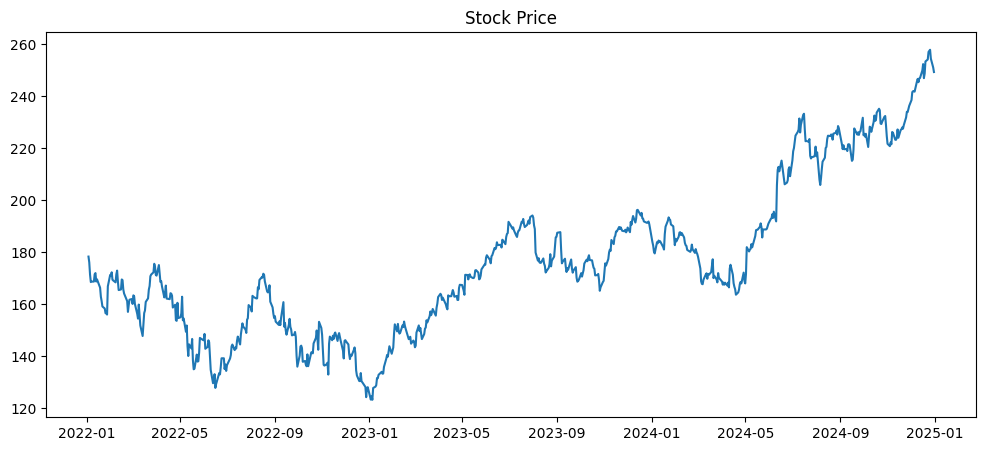

In [219]:
prices = data["Close"].dropna()

plt.figure(figsize=(12,5))
plt.plot(prices)
plt.title("Stock Price")
plt.show()

In [220]:
returns = prices.pct_change().dropna()

returns.head()

Date
2022-01-04   -0.012661
2022-01-05   -0.026618
2022-01-06   -0.016687
2022-01-07    0.000997
2022-01-10    0.000119
Name: Close, dtype: float64

In [221]:
lags = [2,3,5,8,13,21]

weights = np.exp(-np.array(lags)/10)
weights = weights / weights.sum()

In [222]:
def predict_next_linear(window):

    y = np.array(window)
    x = np.arange(len(y))

    # give more weight to recent observations
    w = np.linspace(1, 2, len(y))

    m, c = np.polyfit(x, y, 1, w=w)

    next_x = len(y)

    prediction = m * next_x + c

    return prediction

In [223]:
max_lag = max(lags)

pred_returns = []
actual_returns = []
pred_prices = []
actual_prices = []

ret_vals = returns.values
price_vals = prices.values

for t in range(max_lag, len(ret_vals)):

    preds = []

    for L in lags:

        window = ret_vals[t-L:t]

        v = predict_next_linear(window)

        preds.append(v)

    preds = np.array(preds)

    pred_r = np.sum(weights * preds)

    pred_returns.append(pred_r)
    actual_returns.append(ret_vals[t])

    # convert return prediction to price prediction
    pred_price = price_vals[t-1] * (1 + pred_r)

    pred_prices.append(pred_price)
    actual_prices.append(price_vals[t])

In [224]:
pred_prices = np.array(pred_prices)
actual_prices = np.array(actual_prices)

pred_returns = np.array(pred_returns)
actual_returns = np.array(actual_returns)

In [225]:
mse = mean_squared_error(actual_prices, pred_prices)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices, pred_prices)
r2 = r2_score(actual_prices, pred_prices)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.688673119336668
RMSE: 0.8298633136466921
MAE: 0.630236961109766
R2: 0.9992214908326692


In [226]:
actual_direction = np.sign(actual_returns)
pred_direction = np.sign(pred_returns)

accuracy = np.mean(actual_direction == pred_direction)

print("Direction Accuracy:", accuracy)

Direction Accuracy: 0.5239398084815321


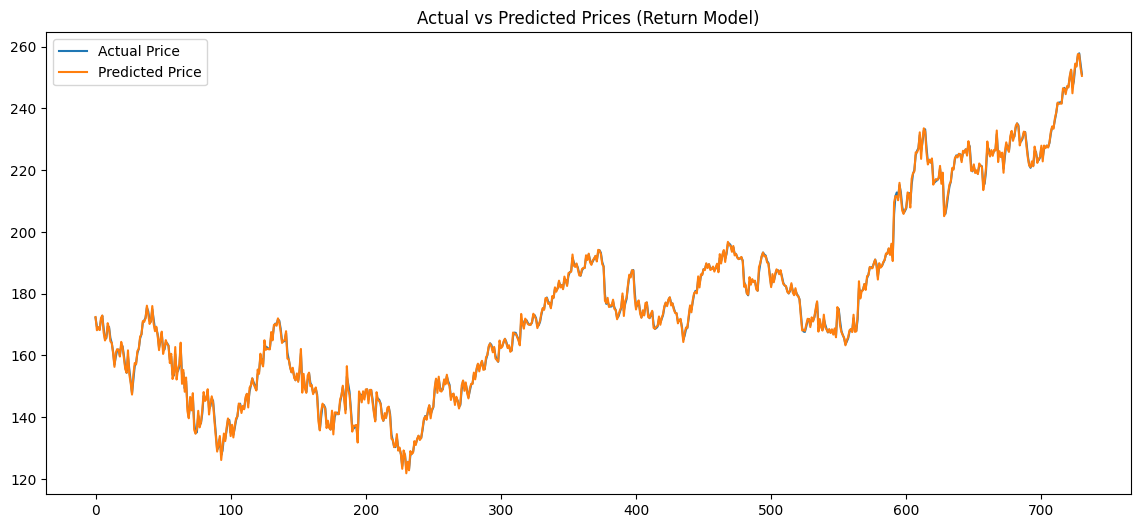

In [227]:
plt.figure(figsize=(14,6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(pred_prices, label="Predicted Price")

plt.legend()
plt.title("Actual vs Predicted Prices (Return Model)")
plt.show()

In [228]:
feature_rows = []
target_returns = []

ret_vals = returns.values

for t in range(max(lags), len(ret_vals)):
    
    preds = []
    
    for L in lags:
        window = ret_vals[t-L:t]
        v = predict_next_linear(window)
        preds.append(v)
    
    feature_rows.append(preds)
    target_returns.append(ret_vals[t])

X = np.array(feature_rows)
y = np.array(target_returns)

print("Feature shape:", X.shape)

Feature shape: (731, 6)


In [229]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Learned weights:", model.coef_)
print("Intercept:", model.intercept_)

Learned weights: [ 0.0247446   0.02849561 -0.09262911 -0.02613255  0.10395146 -0.10960959]
Intercept: 0.00069882815365663


In [230]:
pred_returns_lr = model.predict(X)

pred_prices_lr = []
actual_prices_lr = []

price_vals = prices.values

for i, r in enumerate(pred_returns_lr):
    
    t = i + max(lags)
    
    pred_price = price_vals[t-1] * (1 + r)
    
    pred_prices_lr.append(pred_price)
    actual_prices_lr.append(price_vals[t])

pred_prices_lr = np.array(pred_prices_lr)
actual_prices_lr = np.array(actual_prices_lr)

In [231]:
mse = mean_squared_error(actual_prices_lr, pred_prices_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices_lr, pred_prices_lr)
r2 = r2_score(actual_prices_lr, pred_prices_lr)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 7.986182875989048
RMSE: 2.8259835236584534
MAE: 2.122789448569759
R2: 0.9909720353439574


In [232]:
actual_direction = np.sign(y)
pred_direction = np.sign(pred_returns_lr)

accuracy = np.mean(actual_direction == pred_direction)

print("Direction Accuracy:", accuracy)

Direction Accuracy: 0.5294117647058824


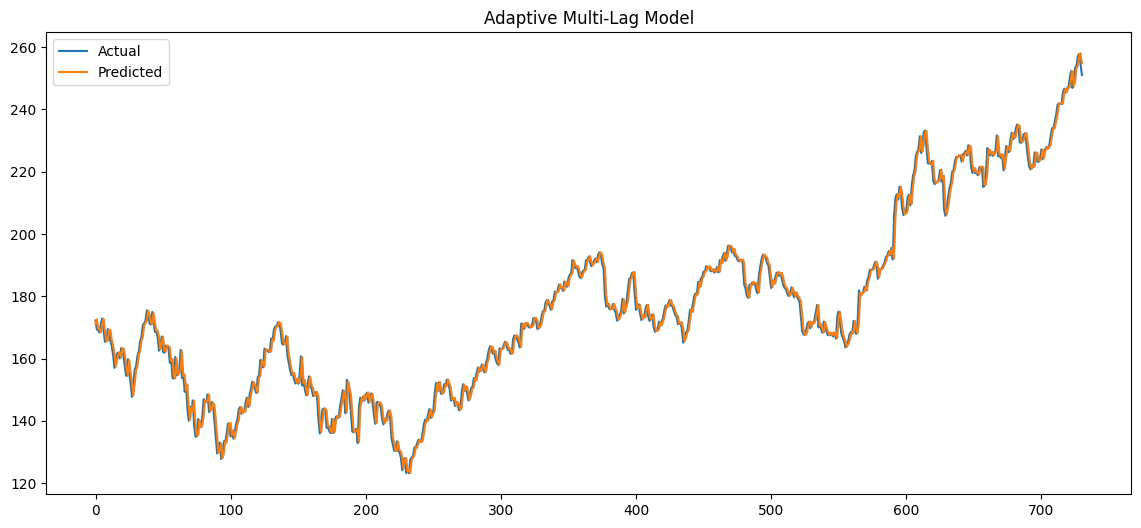

In [233]:
plt.figure(figsize=(14,6))

plt.plot(actual_prices_lr, label="Actual")
plt.plot(pred_prices_lr, label="Predicted")

plt.legend()
plt.title("Adaptive Multi-Lag Model")
plt.show()

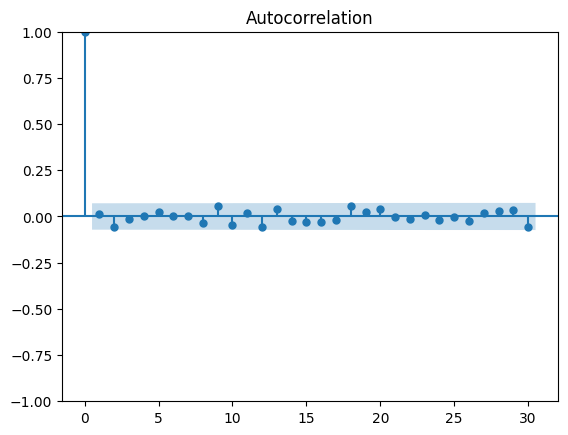

In [234]:
#checking auto corraelation of returns
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(returns, lags=30)
plt.show()

In [235]:
import numpy as np
from statsmodels.tsa.stattools import acf

# Analytical autocorrelation function
def analytical_autocorr(x, lag):
    if lag == 0:
        return 1.0
    return np.corrcoef(x[lag:], x[:-lag])[0, 1]

# Numerical autocorrelation using statsmodels
numerical_acf = acf(returns, nlags=30)

# Check for lags 1 to 30
for lag in range(1, 31):
    analytical = analytical_autocorr(returns.values, lag)
    numerical = numerical_acf[lag]
    print(f"Lag {lag}: Analytical = {analytical:.4f}, Numerical = {numerical:.4f}")

Lag 1: Analytical = 0.0153, Numerical = 0.0153
Lag 2: Analytical = -0.0597, Numerical = -0.0595
Lag 3: Analytical = -0.0152, Numerical = -0.0152
Lag 4: Analytical = 0.0024, Numerical = 0.0024
Lag 5: Analytical = 0.0265, Numerical = 0.0264
Lag 6: Analytical = 0.0030, Numerical = 0.0030
Lag 7: Analytical = 0.0020, Numerical = 0.0020
Lag 8: Analytical = -0.0358, Numerical = -0.0355
Lag 9: Analytical = 0.0558, Numerical = 0.0554
Lag 10: Analytical = -0.0457, Numerical = -0.0453
Lag 11: Analytical = 0.0173, Numerical = 0.0171
Lag 12: Analytical = -0.0589, Numerical = -0.0583
Lag 13: Analytical = 0.0402, Numerical = 0.0398
Lag 14: Analytical = -0.0243, Numerical = -0.0241
Lag 15: Analytical = -0.0287, Numerical = -0.0284
Lag 16: Analytical = -0.0279, Numerical = -0.0276
Lag 17: Analytical = -0.0199, Numerical = -0.0197
Lag 18: Analytical = 0.0562, Numerical = 0.0549
Lag 19: Analytical = 0.0260, Numerical = 0.0253
Lag 20: Analytical = 0.0427, Numerical = 0.0416
Lag 21: Analytical = -0.0044, N

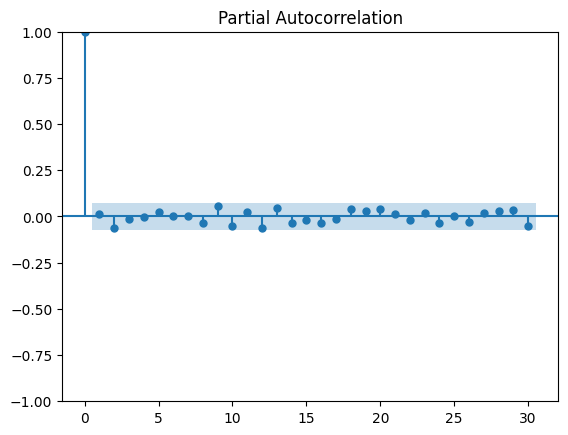

In [236]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(returns, lags=30)
plt.show()

In [237]:
from statsmodels.tsa.stattools import pacf

numerical_pacf = pacf(returns, nlags=10)

for lag in range(1, 11):
    print(f"Lag {lag}: PACF = {numerical_pacf[lag]:.4f}")

Lag 1: PACF = 0.0153
Lag 2: PACF = -0.0599
Lag 3: PACF = -0.0134
Lag 4: PACF = -0.0007
Lag 5: PACF = 0.0249
Lag 6: PACF = 0.0022
Lag 7: PACF = 0.0051
Lag 8: PACF = -0.0352
Lag 9: PACF = 0.0580
Lag 10: PACF = -0.0531


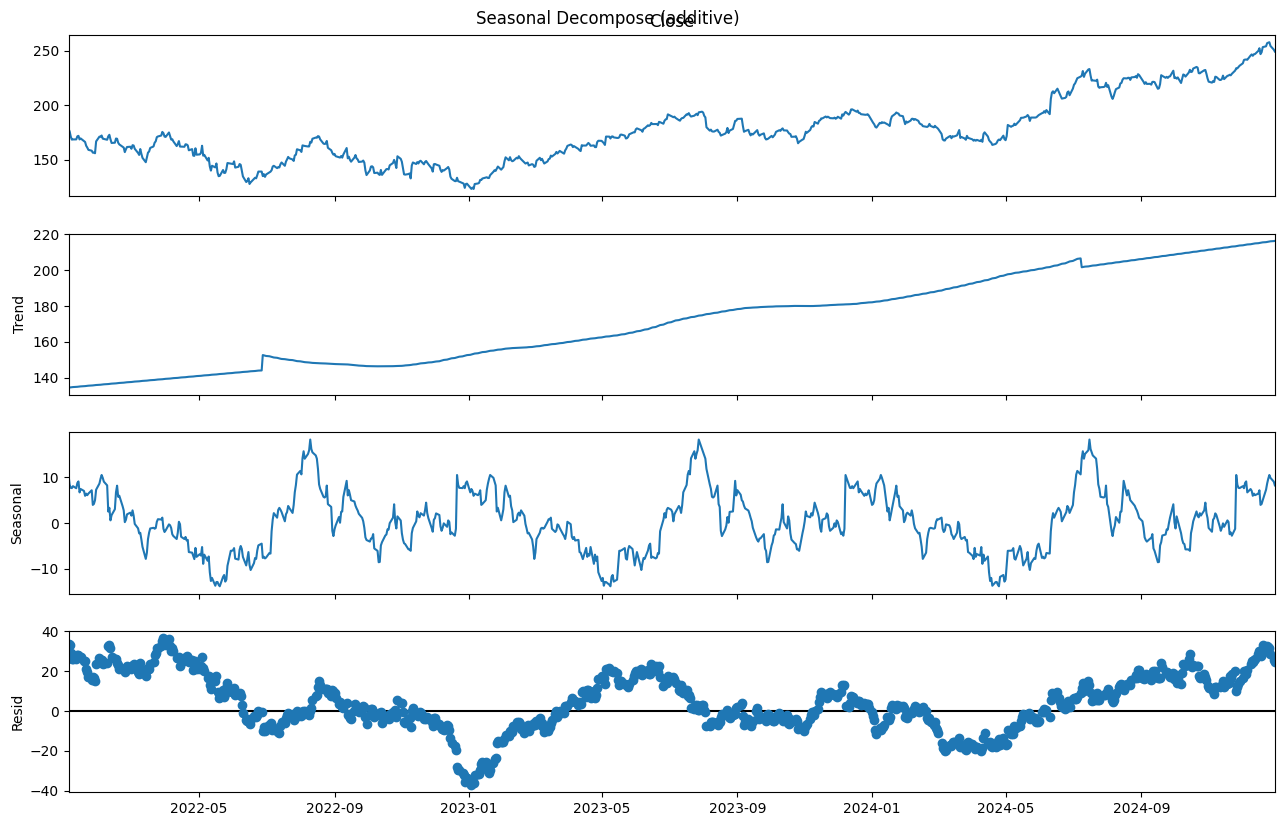

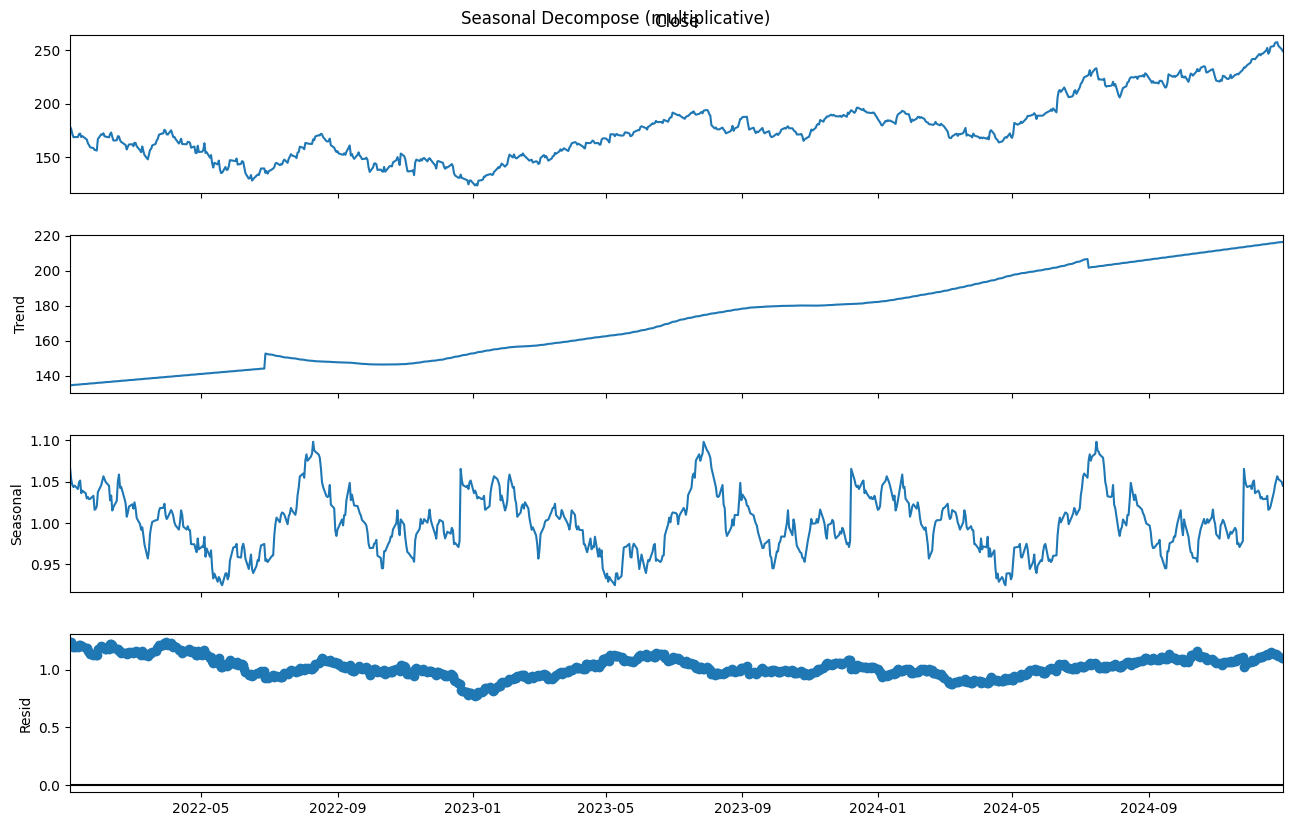

In [238]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ensure business-day frequency for decomposition
prices_b = prices.asfreq('B')
prices_b = prices_b.interpolate(method='time')

for model in ['additive', 'multiplicative']:
    decomp = seasonal_decompose(prices_b, model=model, period=252, extrapolate_trend='freq')
    fig = decomp.plot()
    fig.set_size_inches(14, 9)
    plt.suptitle(f'Seasonal Decompose ({model})', y=0.95)
    plt.show()

In [239]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(returns.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("usedlag:", adf_result[2])
print("nobs:", adf_result[3])
print("critical values:", adf_result[4])
print("icbest:", adf_result[5])

ADF Statistic: -20.42012015522584
p-value: 0.0
usedlag: 1
nobs: 750
critical values: {'1%': -3.439099096730074, '5%': -2.8654013553540745, '10%': -2.568826193777778}
icbest: -3883.786491482425


In [240]:
decomp_mul = seasonal_decompose(prices_b, model='multiplicative', period=252, extrapolate_trend='freq')

for component in ['trend', 'seasonal', 'resid']:
    component_series = getattr(decomp_mul, component).dropna()
    adf_res = adfuller(component_series)
    print(f"{component.capitalize()} ADF statistic: {adf_res[0]:.6f}, p-value: {adf_res[1]:.6f}, nobs: {adf_res[3]}")

Trend ADF statistic: 1.062989, p-value: 0.994888, nobs: 781
Seasonal ADF statistic: -4.127891, p-value: 0.000871, nobs: 760
Resid ADF statistic: -2.618511, p-value: 0.089231, nobs: 771


log_prices head:
Date
2022-01-03    5.183288
2022-01-04    5.170546
2022-01-05    5.143568
2022-01-06    5.126740
2022-01-07    5.127737
Name: Close, dtype: float64

log_diff head:
Date
2022-01-04   -2.257
2022-01-05   -4.685
2022-01-06   -2.859
2022-01-07    0.168
2022-01-10    0.020
Name: Close, dtype: float64


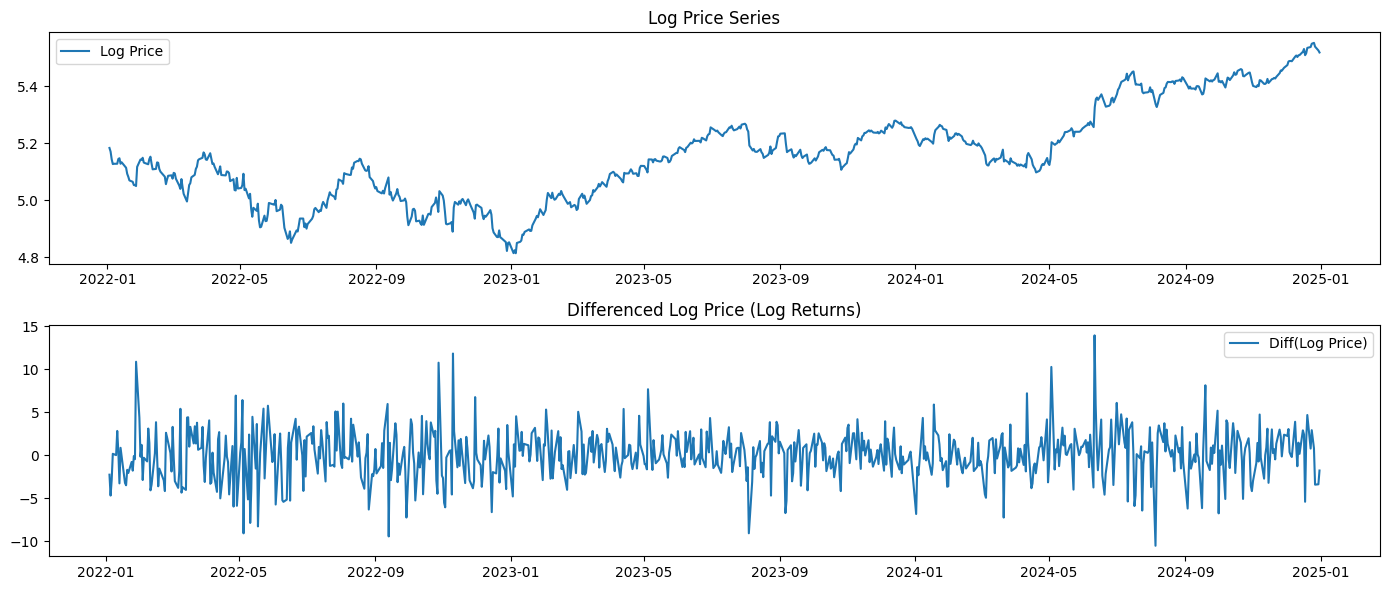

Mean log return: 0.0944468085106383
Std log return: 2.8357210567944073


In [241]:
log_prices = np.log(prices)
log_diff = prices.diff().dropna()

print("log_prices head:")
print(log_prices.head())

print("\nlog_diff head:")
print(log_diff.head())

plt.figure(figsize=(14,6))
plt.subplot(2,1,1)
plt.plot(log_prices, label="Log Price")
plt.title("Log Price Series")
plt.legend()

plt.subplot(2,1,2)
plt.plot(log_diff, label="Diff(Log Price)")
plt.title("Differenced Log Price (Log Returns)")
plt.legend()

plt.tight_layout()
plt.show()

# Optional: compare with pct_change returns
log_returns = log_diff  # same concept
print("Mean log return:", log_returns.mean())
print("Std log return:", log_returns.std())

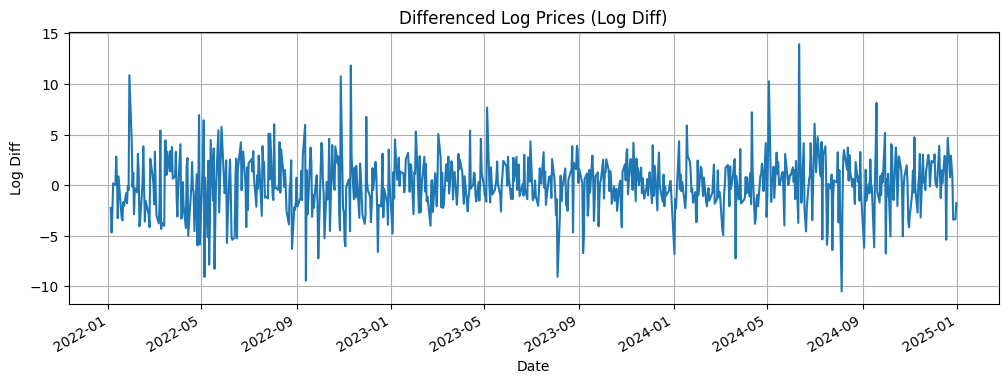

In [242]:
plt.figure(figsize=(12, 4))
log_diff.plot()
plt.title("Differenced Log Prices (Log Diff)")
plt.xlabel("Date")
plt.ylabel("Log Diff")
plt.grid(True)
plt.show()

In [243]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(log_diff.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("usedlag:", adf_result[2])
print("nobs:", adf_result[3])
print("critical values:", adf_result[4])
print("icbest:", adf_result[5])

ADF Statistic: -20.102036529088124
p-value: 0.0
usedlag: 1
nobs: 750
critical values: {'1%': -3.439099096730074, '5%': -2.8654013553540745, '10%': -2.568826193777778}
icbest: 3593.166455585154


In [244]:
from statsmodels.tsa.stattools import acf, pacf

nlags = 30

acf_vals = acf(log_diff.dropna(), nlags=nlags, fft=False)
pacf_vals = pacf(log_diff.dropna(), nlags=nlags, method='ywm')

print("ACF:")
for i, v in enumerate(acf_vals):
    print(f"lag {i}: {v:.6f}")

print("\nPACF:")
for i, v in enumerate(pacf_vals):
    print(f"lag {i}: {v:.6f}")

ACF:
lag 0: 1.000000
lag 1: 0.030893
lag 2: -0.051311
lag 3: -0.020983
lag 4: 0.020803
lag 5: 0.009578
lag 6: 0.004099
lag 7: 0.011890
lag 8: -0.028879
lag 9: 0.045117
lag 10: -0.038279
lag 11: 0.006698
lag 12: -0.053208
lag 13: 0.039399
lag 14: -0.021190
lag 15: -0.026925
lag 16: -0.045553
lag 17: -0.010900
lag 18: 0.042411
lag 19: 0.025286
lag 20: 0.035497
lag 21: 0.003469
lag 22: 0.007071
lag 23: 0.005887
lag 24: -0.019061
lag 25: -0.007951
lag 26: -0.010440
lag 27: 0.029202
lag 28: 0.016184
lag 29: 0.038095
lag 30: -0.046915

PACF:
lag 0: 1.000000
lag 1: 0.030893
lag 2: -0.052315
lag 3: -0.017764
lag 4: 0.019438
lag 5: 0.006334
lag 6: 0.005283
lag 7: 0.013241
lag 8: -0.029436
lag 9: 0.048367
lag 10: -0.044361
lag 11: 0.012650
lag 12: -0.055879
lag 13: 0.041724
lag 14: -0.029102
lag 15: -0.022056
lag 16: -0.045807
lag 17: -0.007584
lag 18: 0.033355
lag 19: 0.027704
lag 20: 0.032819
lag 21: 0.015935
lag 22: 0.000819
lag 23: 0.013319
lag 24: -0.027940
lag 25: -0.000796
lag 26: -0.0189

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it

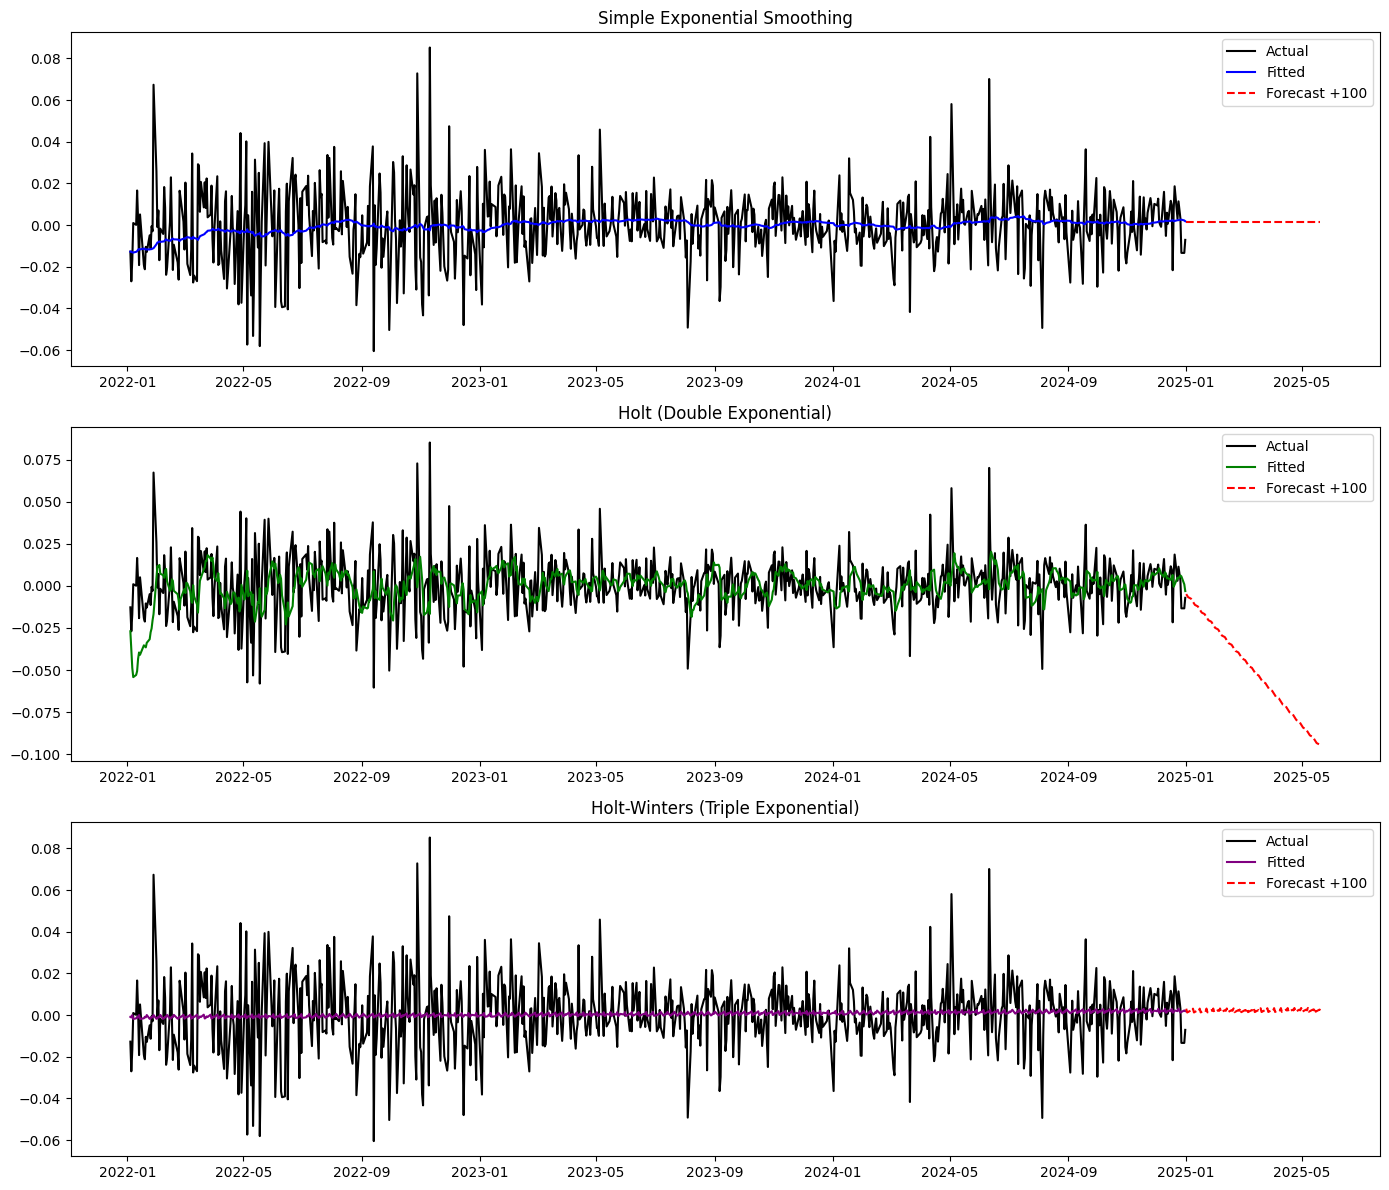

In [249]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

returns_series = np.log(prices).diff().dropna()
n_forecast = 100

# -------------------------
# 1) SES
# -------------------------
ses_model = SimpleExpSmoothing(returns_series).fit(optimized=True)
ses_fitted = ses_model.fittedvalues
ses_forecast = ses_model.forecast(n_forecast)

# -------------------------
# 2) Holt
# -------------------------
holt_model = Holt(returns_series).fit(optimized=True)
holt_fitted = holt_model.fittedvalues
holt_forecast = holt_model.forecast(n_forecast)

# -------------------------
# 3) Holt-Winters
# -------------------------
hw_model = ExponentialSmoothing(
    returns_series,
    trend="add",
    seasonal="add",
    seasonal_periods=5
).fit(optimized=True)

hw_fitted = hw_model.fittedvalues
hw_forecast = hw_model.forecast(n_forecast)


# -------------------------
# Create future index
# -------------------------
if isinstance(returns_series.index, pd.DatetimeIndex):
    future_index = pd.bdate_range(
        start=returns_series.index[-1] + pd.Timedelta(days=1),
        periods=n_forecast
    )
else:
    future_index = pd.RangeIndex(
        start=len(returns_series),
        stop=len(returns_series) + n_forecast
    )

ses_forecast.index = future_index
holt_forecast.index = future_index
hw_forecast.index = future_index


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(14,12))

# SES
plt.subplot(3,1,1)
plt.plot(returns_series, label="Actual", color="black")
plt.plot(ses_fitted, label="Fitted", color="blue")
plt.plot(ses_forecast, label="Forecast +100", linestyle="--", color="red")
plt.title("Simple Exponential Smoothing")
plt.legend()


# Holt
plt.subplot(3,1,2)
plt.plot(returns_series, label="Actual", color="black")
plt.plot(holt_fitted, label="Fitted", color="green")
plt.plot(holt_forecast, label="Forecast +100", linestyle="--", color="red")
plt.title("Holt (Double Exponential)")
plt.legend()


# Holt-Winters
plt.subplot(3,1,3)
plt.plot(returns_series, label="Actual", color="black")
plt.plot(hw_fitted, label="Fitted", color="purple")
plt.plot(hw_forecast, label="Forecast +100", linestyle="--", color="red")
plt.title("Holt-Winters (Triple Exponential)")
plt.legend()

plt.tight_layout()
plt.show()

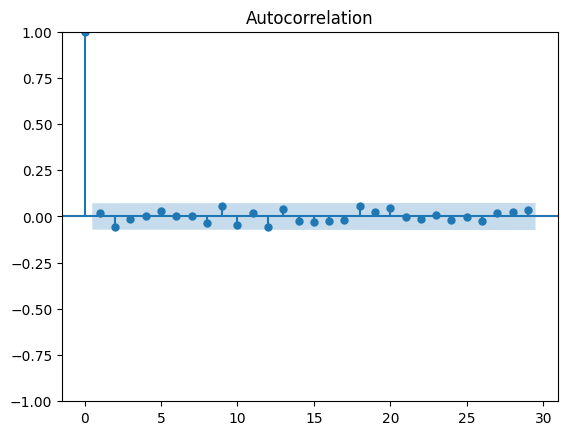

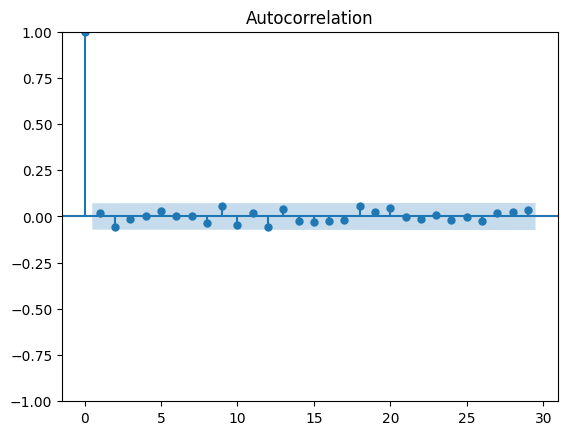

In [250]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(returns_series)

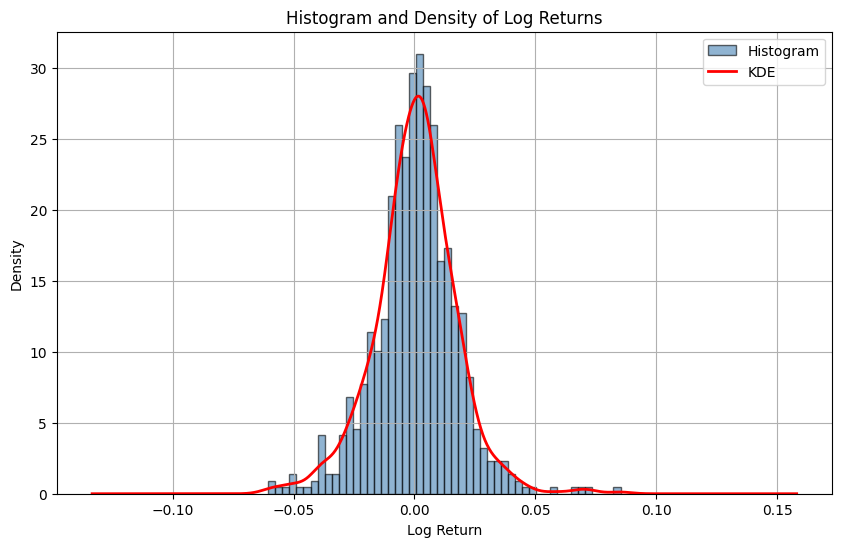

In [251]:
plt.figure(figsize=(10,6))

# histogram
returns_series.hist(
    bins=50,
    density=True,
    alpha=0.6,
    color="steelblue",
    edgecolor="black",
    label="Histogram",
)

# density curve
returns_series.plot(
    kind="kde",
    color="red",
    linewidth=2,
    label="KDE",
)

plt.title("Histogram and Density of Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()